# P02：描述性统计、可视化与回归分析

**作业编号**：ex_P02  
**姓名**：李贤记  
**版本号**：v1  

> 本 Notebook 为第四、五部分：描述性统计与可视化、CAPM 回归分析。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

PROJECT_ROOT = "dshw-p01"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STOCK_LIST = [
    {"code": "600036", "name": "招商银行", "industry": "银行"},
    {"code": "601398", "name": "工商银行", "industry": "银行"},
    {"code": "002594", "name": "比亚迪",   "industry": "汽车"},
    {"code": "600519", "name": "贵州茅台", "industry": "白酒"},
    {"code": "000858", "name": "五粮液",   "industry": "白酒"},
    {"code": "000002", "name": "万科A",    "industry": "房地产"},
    {"code": "601857", "name": "中国石油", "industry": "能源"},
    {"code": "600028", "name": "中国石化", "industry": "能源"},
    {"code": "000063", "name": "中兴通讯", "industry": "通讯"},
    {"code": "002352", "name": "顺丰控股", "industry": "物流"},
]
STOCK_INFO = {s["code"]: s for s in STOCK_LIST}

INDUSTRY_COLORS = {
    "银行": "#1f77b4", "汽车": "#ff7f0e", "白酒": "#d62728",
    "房地产": "#9467bd", "能源": "#2ca02c", "通讯": "#8c564b", "物流": "#e377c2"
}
INDUSTRY_ORDER = ["银行", "白酒", "汽车", "房地产", "能源", "通讯", "物流"]

print("环境加载完成。")

环境加载完成。


In [5]:
# ========== 读取数据 ==========
df_combined = pd.read_csv(f"{PROJECT_ROOT}/data/combined/combined_data.csv")
df_combined["date"] = pd.to_datetime(df_combined["date"])
df_combined["code"] = df_combined["code"].astype(str).str.zfill(6)
df_combined = df_combined.drop_duplicates(subset=["date", "code"]).reset_index(drop=True)

print(f"综合数据：{df_combined.shape}")
print(f"股票数：{df_combined['code'].nunique()}")

df_hs300 = pd.read_csv(f"{PROJECT_ROOT}/data/index/index_000300.csv")
df_hs300["date"] = pd.to_datetime(df_hs300["date"])
df_hs300["close"] = pd.to_numeric(df_hs300["close"], errors="coerce")
print(f"沪深300：{df_hs300.shape}")

综合数据：(15150, 16)
股票数：10
沪深300：(1515, 7)


In [6]:
# ========== 构建宽表 ==========
df_pivot_close = df_combined.pivot_table(index="date", columns="code", values="close")
df_pivot_close = df_pivot_close.sort_index()

df_returns = np.log(df_pivot_close / df_pivot_close.shift(1)).dropna()

print(f"收盘价宽表：{df_pivot_close.shape}")
print(f"收益率宽表：{df_returns.shape}")

收盘价宽表：(1515, 10)
收益率宽表：(1514, 10)


---
## 第四部分：描述性统计与可视化

### 4.1 基本统计量

计算 10 只股票日对数收益率的描述性统计。

In [7]:
def max_drawdown(prices):
    cummax = prices.cummax()
    drawdown = (prices - cummax) / cummax
    return drawdown.min()

stat_rows = []
for code in df_returns.columns:
    r = df_returns[code].dropna()
    info = STOCK_INFO[str(code)]
    prices = df_pivot_close[code].dropna()
    stat_rows.append({
        "股票": info["name"], "代码": code, "行业": info["industry"],
        "年化均值": f"{r.mean() * 252:.4f}",
        "年化波动率": f"{r.std() * np.sqrt(252):.4f}",
        "偏度": f"{r.skew():.4f}",
        "峰度": f"{r.kurtosis():.4f}",
        "最大回撤": f"{max_drawdown(prices):.2%}",
    })

df_stats = pd.DataFrame(stat_rows)
print("10 只股票日收益率描述性统计：")
display(df_stats)

10 只股票日收益率描述性统计：


,股票,代码,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,万科A,000002,房地产,-0.3243,0.3640,0.6556,3.2536,-86.73%
1,中兴通讯,000063,通讯,-0.0019,0.4260,0.3093,2.4854,-61.87%
2,五粮液,000858,白酒,-0.0136,0.3454,0.0880,3.3162,-66.09%
3,顺丰控股,002352,物流,0.0158,0.3243,0.3763,3.5476,-70.77%
4,比亚迪,002594,汽车,0.3060,0.4330,0.3044,2.0912,-52.54%
5,中国石化,600028,能源,0.0860,0.2335,0.3550,5.3676,-25.06%
6,招商银行,600036,银行,0.0468,0.2773,0.2649,3.1522,-50.94%
7,贵州茅台,600519,白酒,0.0642,0.2770,0.2629,3.6141,-47.48%
8,工商银行,601398,银行,0.0924,0.1628,0.4559,5.8204,-20.20%
9,中国石油,601857,能源,0.1754,0.2927,0.2183,5.1691,-32.47%


**统计量解读：**

- **年化均值**反映了各股票在样本期内的平均收益水平。能源和银行板块通常收益较稳定；汽车（比亚迪）受新能源行情驱动可能年化均值较高。
- **年化波动率**衡量风险大小。白酒、汽车等消费/成长板块波动率通常高于银行等低波板块。
- **偏度**多数股票呈负偏（左偏），说明大幅下跌的概率高于大幅上涨，这与 A 股"暴跌多于暴涨"的经验一致。
- **峰度**均显著大于 0（超额峰度），说明收益率分布存在"厚尾"现象，极端收益出现的概率高于正态分布。
- **最大回撤**反映极端风险敞口，房地产（万科A）在行业下行周期中回撤通常较大。

### 4.2 可视化

#### 图 1：归一化收盘价走势图

以首个交易日 = 1 为基准，绘制 10 只股票及沪深 300 的归一化走势。

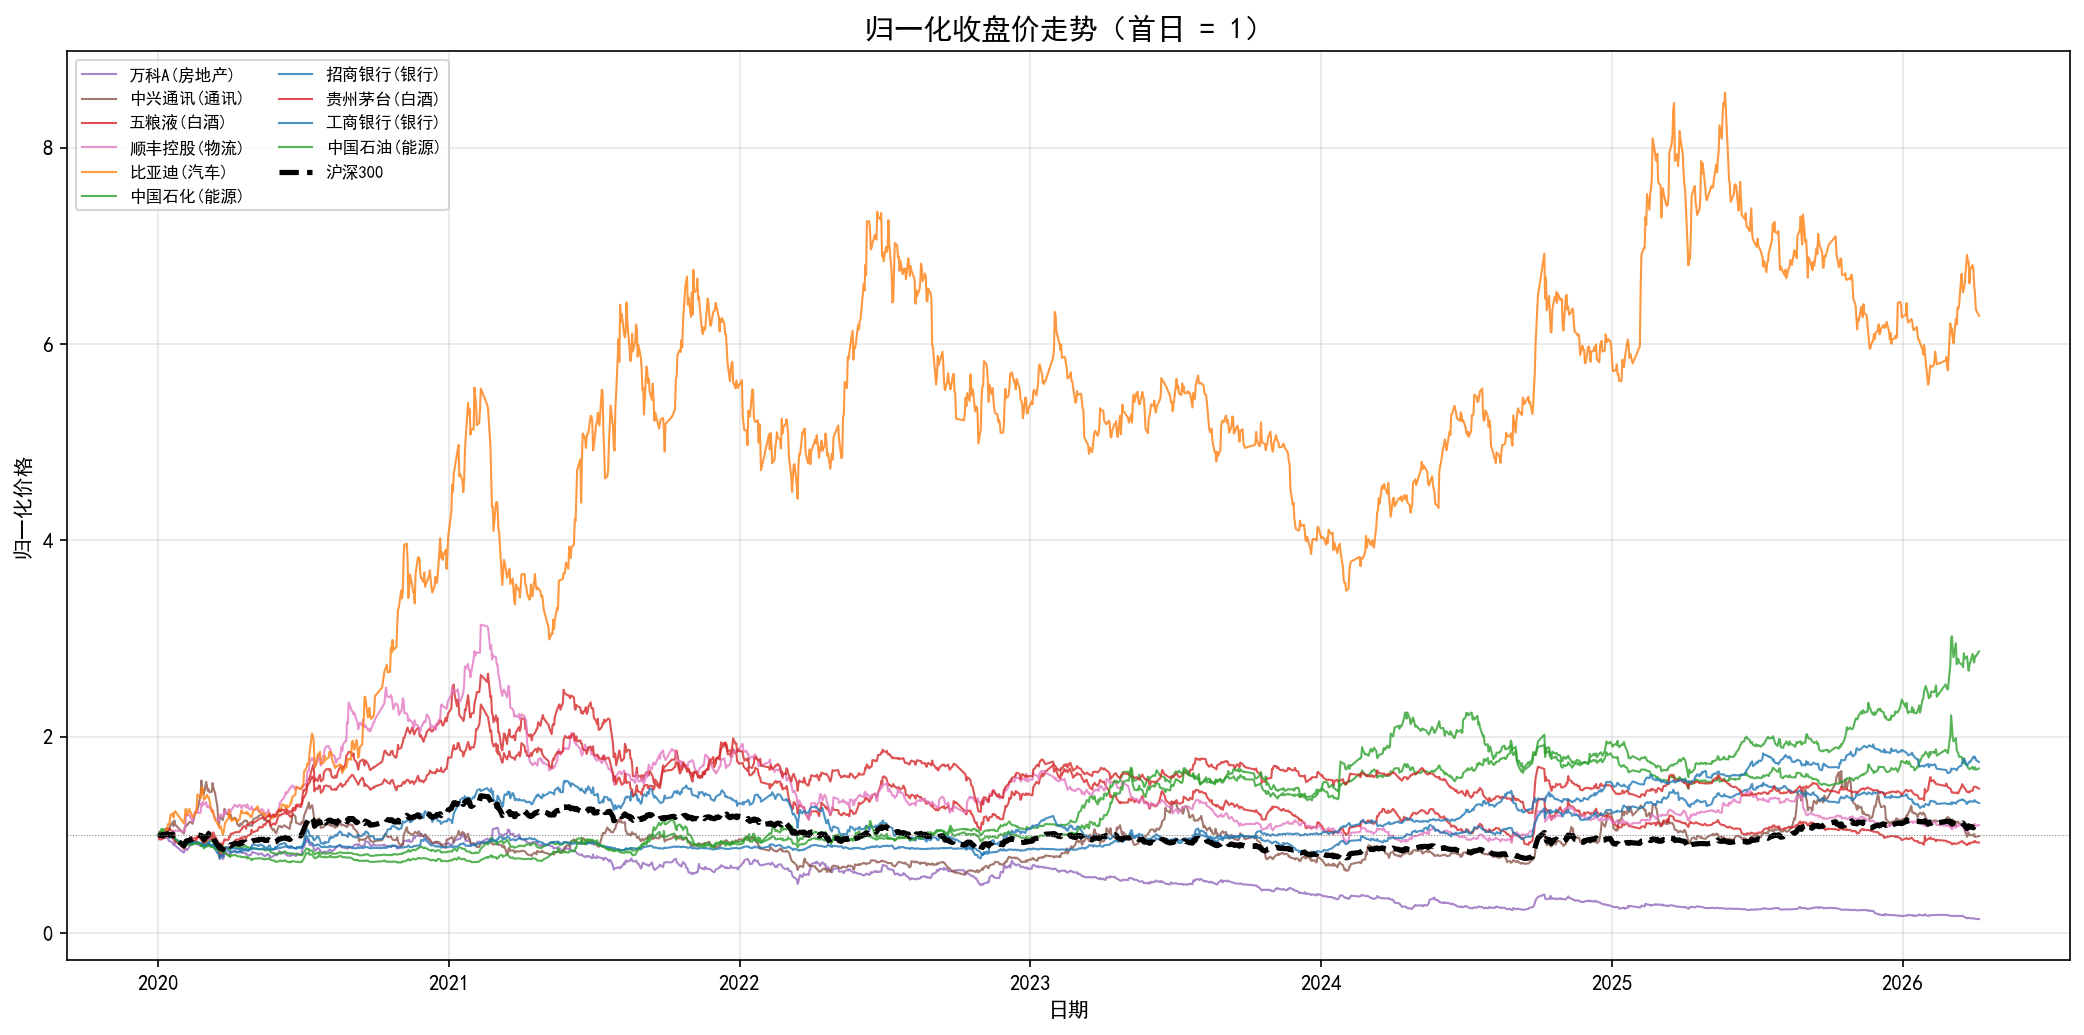

图 1 已保存


In [8]:
df_norm = df_pivot_close / df_pivot_close.iloc[0]

hs300_close = df_hs300.set_index("date")["close"].sort_index()
hs300_norm = hs300_close / hs300_close.iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
for code in df_norm.columns:
    info = STOCK_INFO[str(code)]
    color = INDUSTRY_COLORS[info["industry"]]
    ax.plot(df_norm.index, df_norm[code], color=color,
            alpha=0.8, linewidth=1, label=f"{info['name']}({info['industry']})")

ax.plot(hs300_norm.index, hs300_norm, color="black",
        linewidth=2.5, linestyle="--", label="沪深300")

ax.axhline(y=1, color="gray", linewidth=0.5, linestyle=":")
ax.set_title("归一化收盘价走势（首日 = 1）", fontsize=14)
ax.set_xlabel("日期")
ax.set_ylabel("归一化价格")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_normalized_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("图 1 已保存")

**图 1 解读：**

从归一化走势图可以看出，不同行业的股票在 2020-2026 年间表现分化显著。比亚迪（汽车）受益于新能源产业政策，涨幅远超大盘；银行股走势平稳，与沪深 300 走势较为接近；万科A（房地产）在行业调控后持续下行，跑输大盘。能源板块在 2021-2022 年能源价格上涨期间有明显上行。整体来看，行业选择对投资回报的影响远大于市场整体涨跌。

#### 图 2：日收益率分布图

10 只股票收益率分面直方图（2 行 x 5 列），每个子图叠加正态分布曲线，标注均值和标准差。

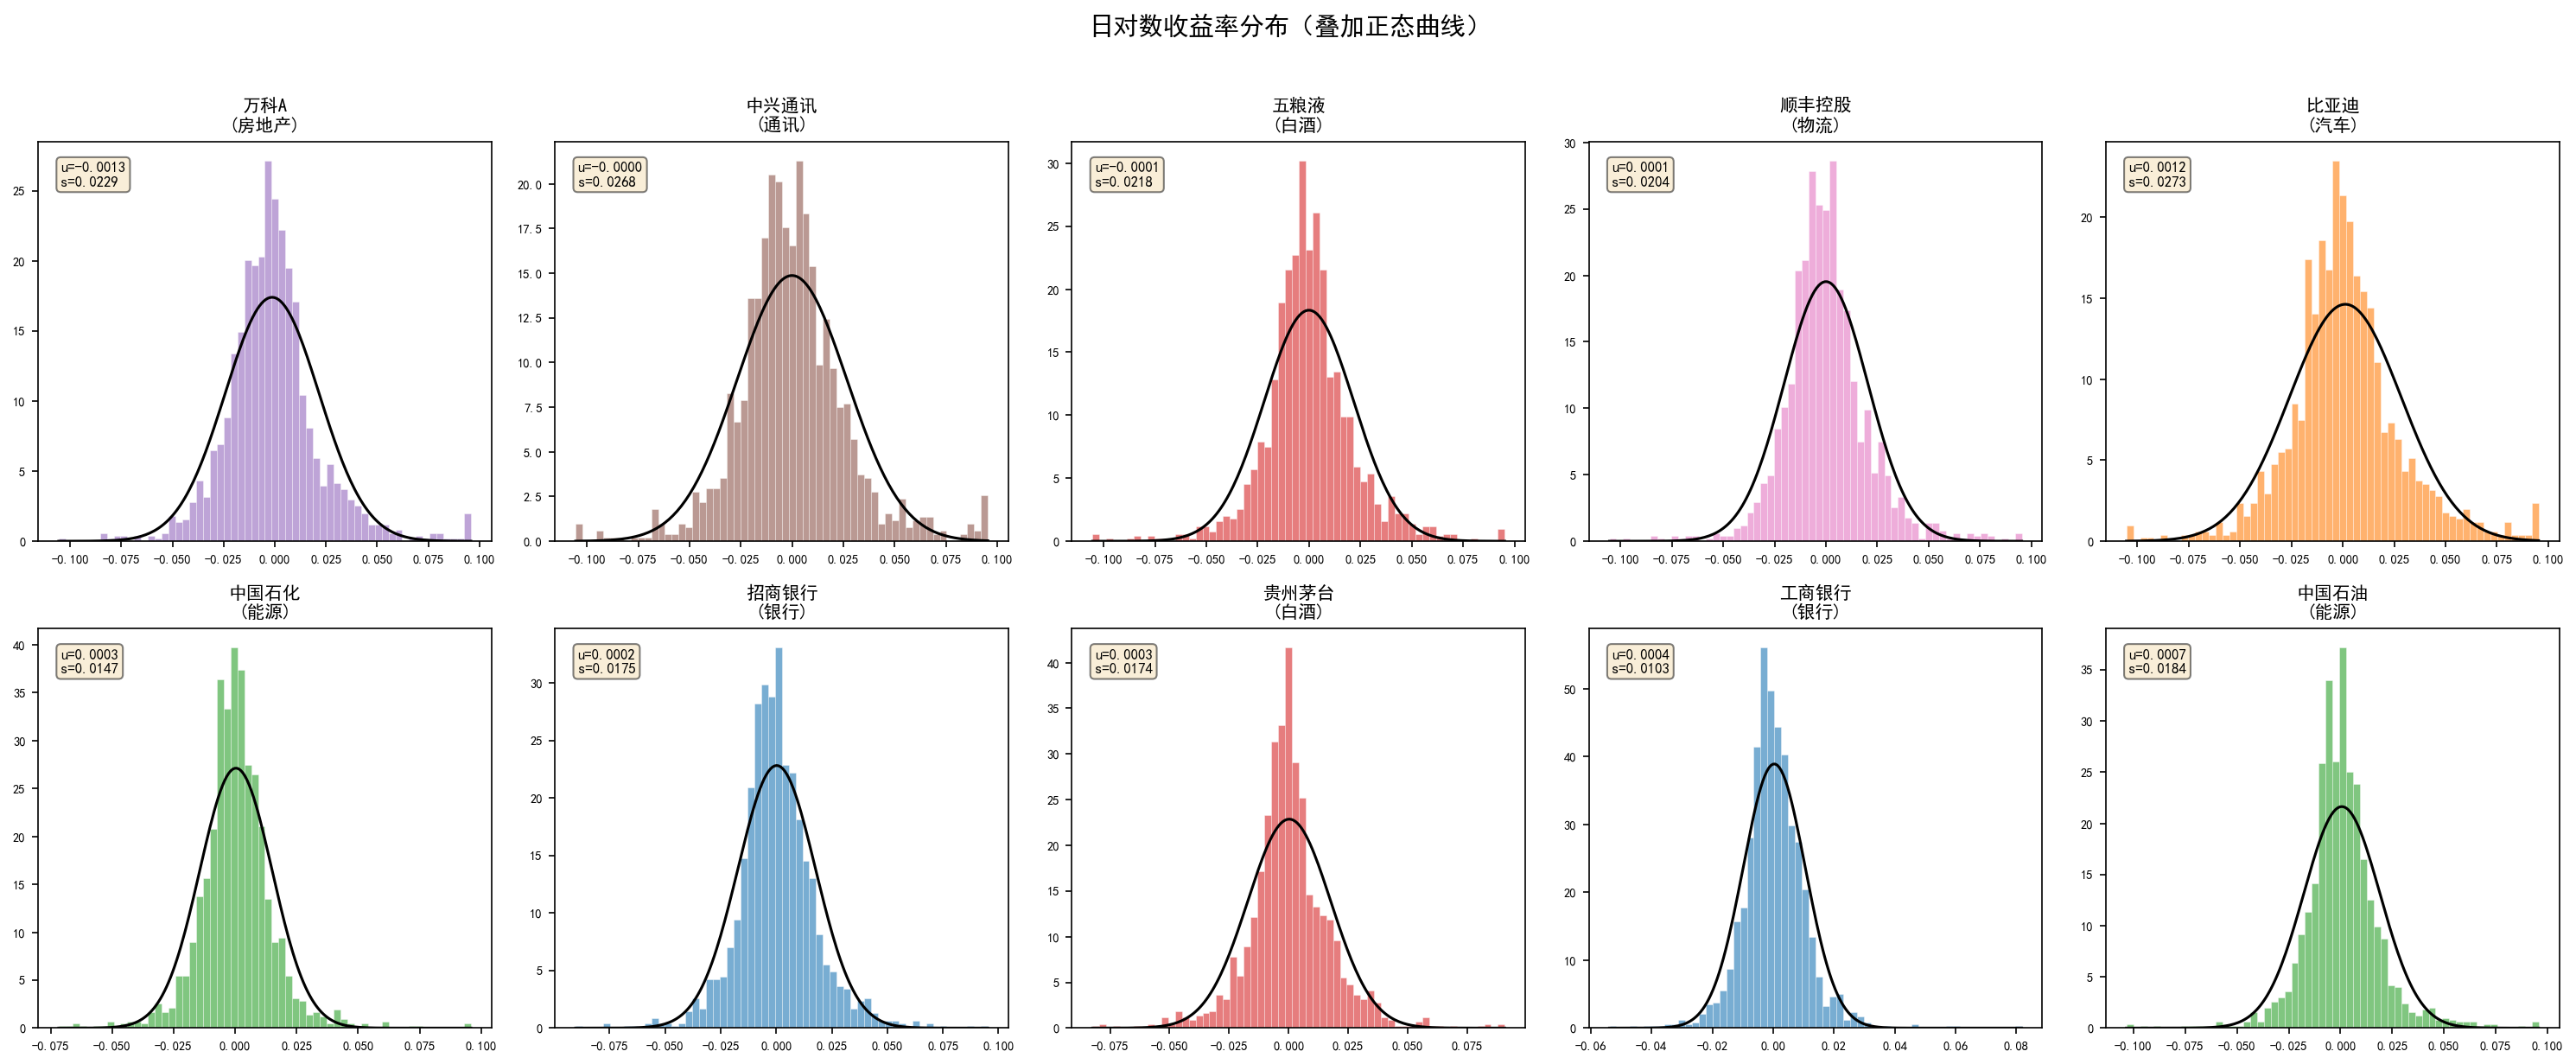

图 2 已保存


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, code in enumerate(df_returns.columns):
    ax = axes[i]
    r = df_returns[code].dropna()
    info = STOCK_INFO[str(code)]
    mu, sigma = r.mean(), r.std()

    ax.hist(r, bins=60, density=True, alpha=0.6,
            color=INDUSTRY_COLORS[info["industry"]], edgecolor="white", linewidth=0.3)

    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', linewidth=1.5)

    ax.set_title(f"{info['name']}\n({info['industry']})", fontsize=10)
    ax.text(0.05, 0.95, f"u={mu:.4f}\ns={sigma:.4f}",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax.tick_params(labelsize=7)

plt.suptitle("日对数收益率分布（叠加正态曲线）", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("图 2 已保存")

**图 2 解读：**

所有股票的收益率分布均呈现"尖峰厚尾"特征：分布中心比正态分布更集中（尖峰），但两侧极端值出现频率更高（厚尾）。这说明正态分布假设低估了金融资产的极端风险。比亚迪、万科A 等波动率较高的股票，其分布更为分散；银行股的分布则更集中、尾部更薄，反映了其低波动的防御性特征。

#### 图 3：收益率相关系数热力图

按行业对股票排序，标注具体数值。

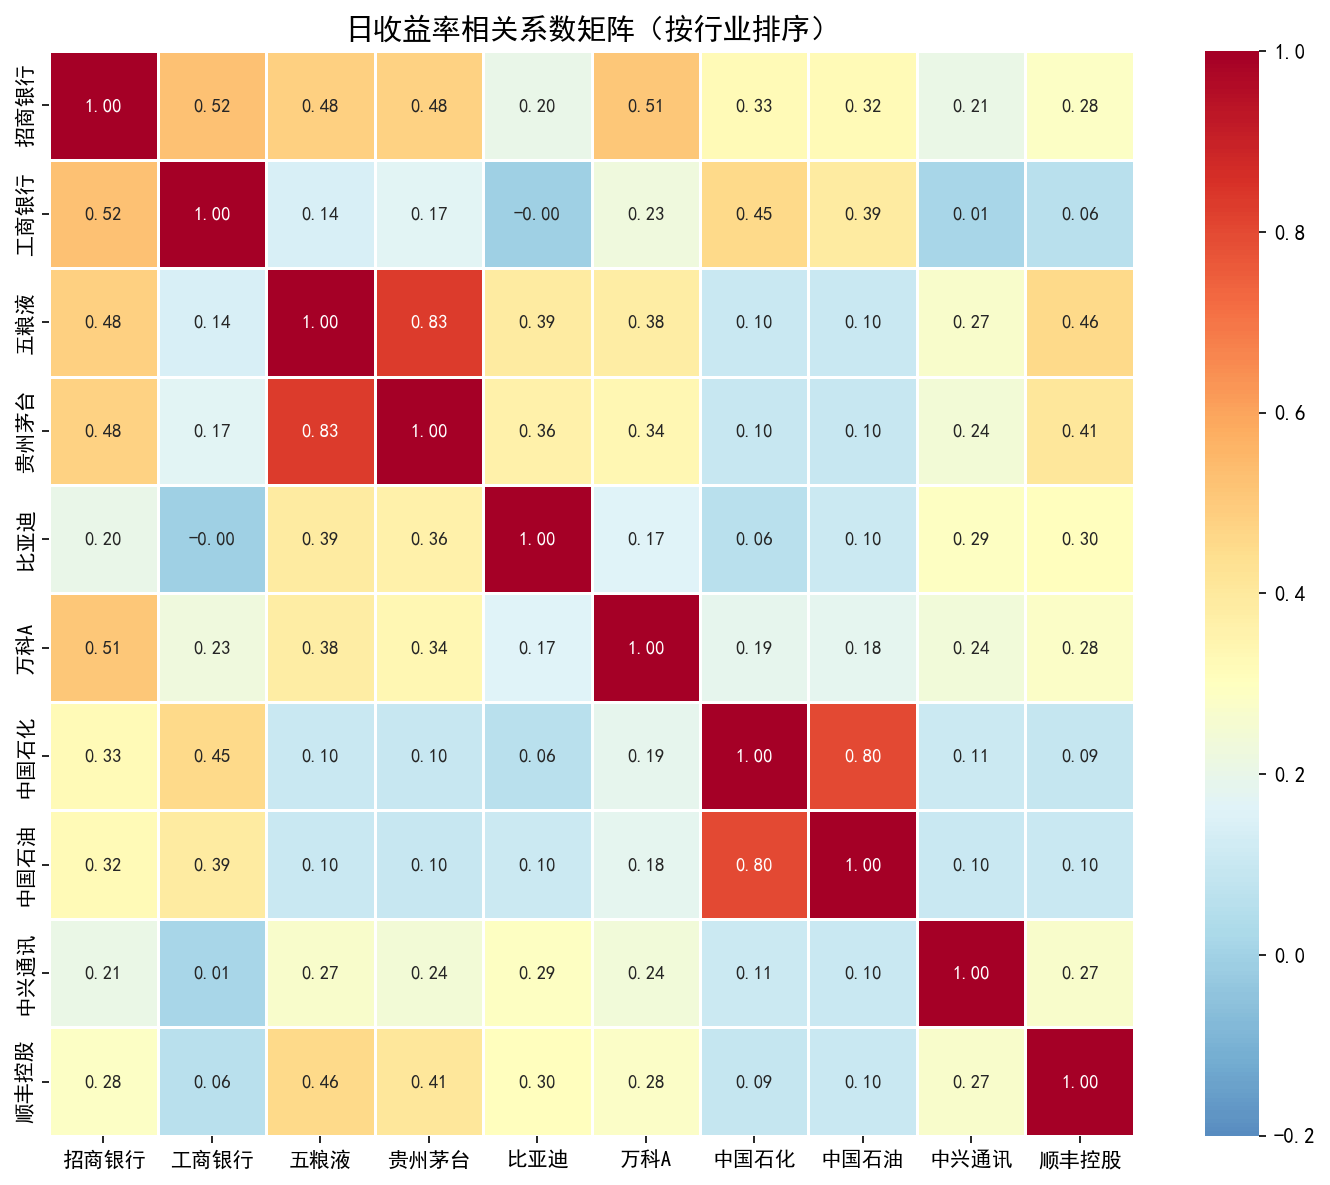

图 3 已保存


In [10]:
sorted_codes = sorted(df_returns.columns,
                      key=lambda c: (INDUSTRY_ORDER.index(STOCK_INFO[str(c)]["industry"]), c))
sorted_names = [STOCK_INFO[str(c)]["name"] for c in sorted_codes]

corr_matrix = df_returns[sorted_codes].corr()
corr_matrix.index = sorted_names
corr_matrix.columns = sorted_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r",
            vmin=-0.2, vmax=1, center=0.3, square=True,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("日收益率相关系数矩阵（按行业排序）", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("图 3 已保存")

**图 3 解读：**

从热力图可以看出，**同行业内的相关性明显高于跨行业**：银行板块的招商银行与工商银行相关性较高；白酒板块的贵州茅台与五粮液相关性较高；能源板块的中国石油与中国石化也呈现较强正相关。这符合预期——同行业公司受相同的政策环境、供需周期和市场情绪驱动。跨行业之间相关性较低，说明行业分散化配置可以有效降低组合风险。

#### 图 4：宏观指标与股市关系

M2 同比增速与沪深 300 月度收益率的散点图，叠加线性拟合线。

In [11]:
hs300_monthly = df_hs300.set_index("date")["close"].resample("ME").last()
hs300_monthly_ret = np.log(hs300_monthly / hs300_monthly.shift(1)).dropna()
hs300_monthly_ret.name = "hs300_ret"
hs300_monthly_ret.index = hs300_monthly_ret.index.to_period("M")

df_m2 = pd.read_csv(f"{PROJECT_ROOT}/data/macro/macro_m2.csv")
df_m2["date"] = pd.to_datetime(df_m2["date"])
df_m2["ym"] = df_m2["date"].dt.to_period("M")
df_m2 = df_m2.set_index("ym")["m2_yoy"]

df_macro_plot = pd.DataFrame({"hs300_ret": hs300_monthly_ret, "m2_yoy": df_m2}).dropna()
print(f"有效月份数：{len(df_macro_plot)}")

有效月份数：73


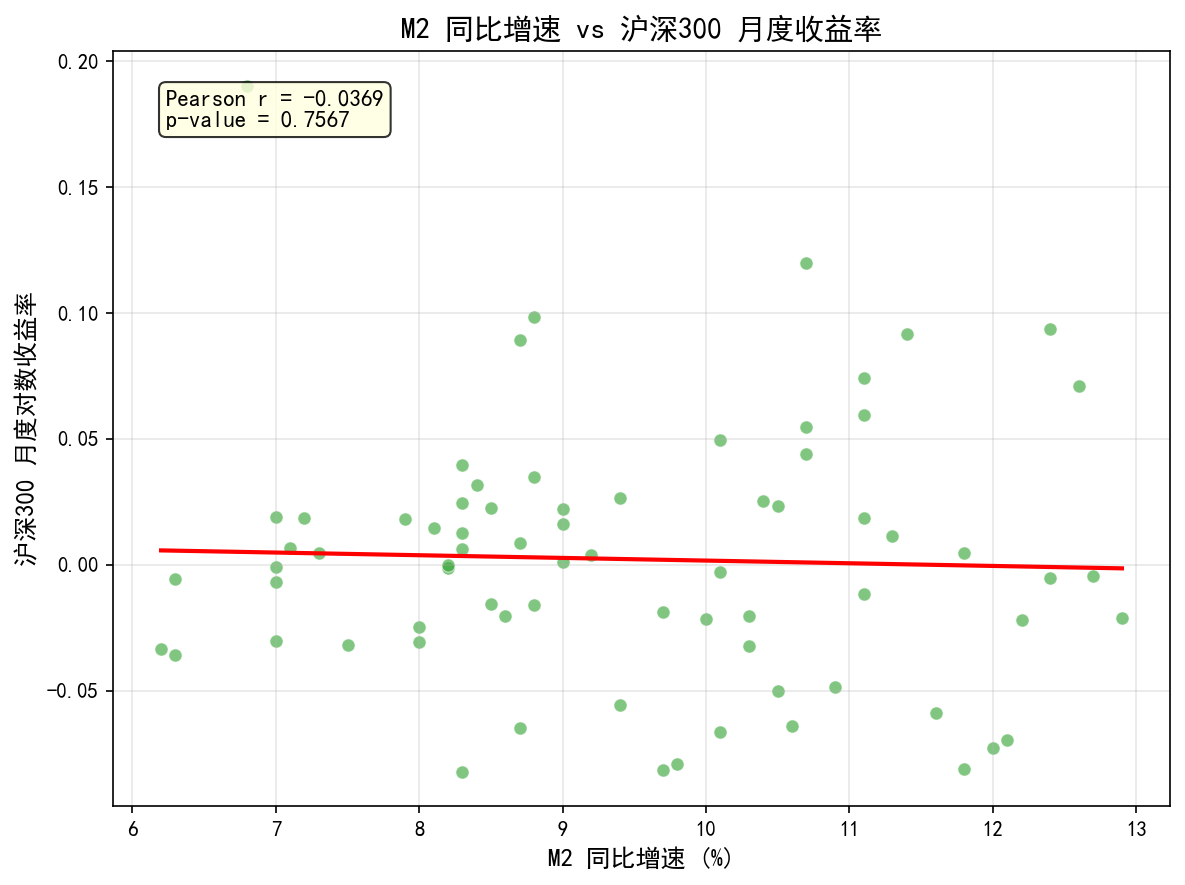

图 4 已保存


In [12]:
x = df_macro_plot["m2_yoy"].values
y = df_macro_plot["hs300_ret"].values
pearson_r, pearson_p = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.6, s=40, c="#2ca02c", edgecolors="white", linewidth=0.5)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), "r-", linewidth=2)

ax.set_xlabel("M2 同比增速 (%)", fontsize=12)
ax.set_ylabel("沪深300 月度对数收益率", fontsize=12)
ax.set_title("M2 同比增速 vs 沪深300 月度收益率", fontsize=14)
ax.text(0.05, 0.95, f"Pearson r = {pearson_r:.4f}\np-value = {pearson_p:.4f}",
        transform=ax.transAxes, fontsize=11, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_m2_vs_hs300.png", dpi=150, bbox_inches="tight")
plt.show()
print("图 4 已保存")

**图 4 解读：**

M2 同比增速与沪深 300 月度收益率之间的线性关系较弱。M2 增速上升代表货币政策偏宽松、流动性充裕，理论上有利于股市。但实际关系受到多重因素干扰：（1）货币政策的传导存在时滞；（2）M2 增速上升有时伴随经济下行（逆周期调节），此时宽松政策未必能立即提振股市。因此同期相关性可能被稀释。

#### 图 5（选做）：财务指标跨公司对比

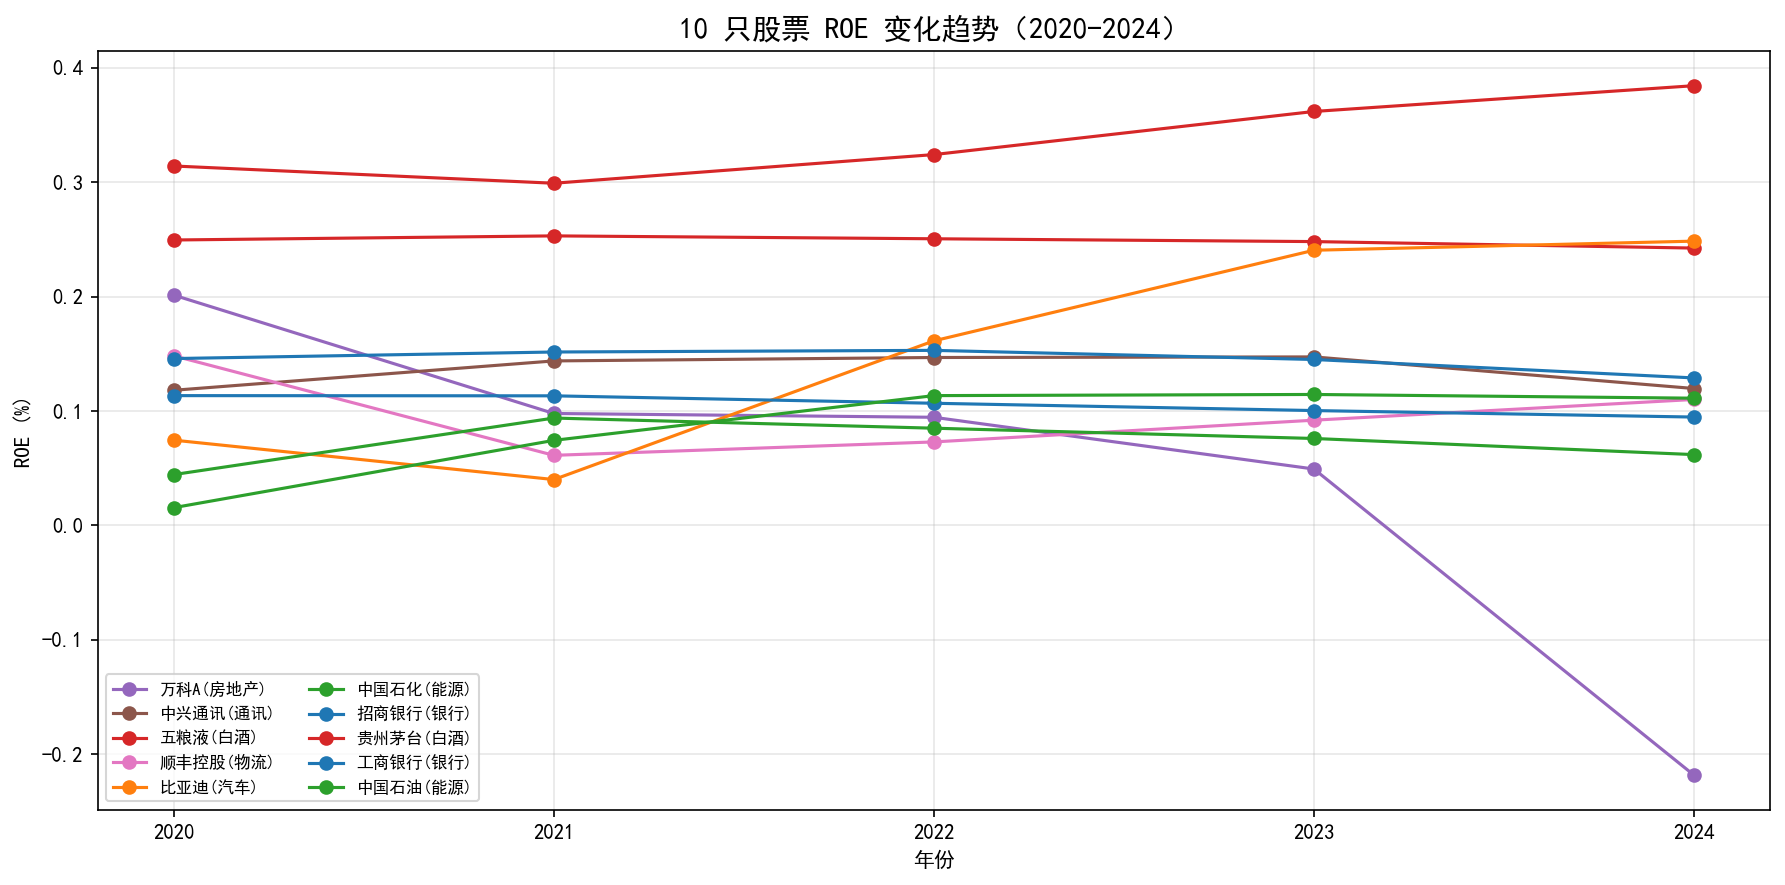

图 5 已保存


In [13]:
df_fin = pd.read_csv(f"{PROJECT_ROOT}/data/finance/finance_ratios.csv")
df_roe = df_fin[df_fin["indicator"] == "ROE"].copy()
df_roe["code"] = df_roe["code"].astype(str).str.zfill(6)

fig, ax = plt.subplots(figsize=(12, 6))
for _, row_group in df_roe.groupby("code"):
    code = row_group["code"].iloc[0]
    info = STOCK_INFO.get(code, {})
    name = info.get("name", code)
    industry = info.get("industry", "other")
    color = INDUSTRY_COLORS.get(industry, "gray")
    ax.plot(row_group["year"], row_group["value"],
            marker="o", color=color, linewidth=1.5, label=f"{name}({industry})")

ax.set_title("10 只股票 ROE 变化趋势（2020-2024）", fontsize=14)
ax.set_xlabel("年份")
ax.set_ylabel("ROE (%)")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_roe_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("图 5 已保存")

**图 5 解读：**

不同行业的 ROE 水平和趋势差异明显。白酒行业 ROE 持续保持较高水平，体现了其高毛利率和强品牌溢价；银行业 ROE 稳定但近年有所下降；房地产 ROE 下降幅度较大，与行业调控政策密切相关；比亚迪 ROE 呈上升趋势，反映新能源汽车销量快速增长。

---
## 第五部分：回归分析

### 5.1 CAPM 模型估计

$$r_{i,t} - r_f = \alpha_i + \beta_i (r_{m,t} - r_f) + \varepsilon_{i,t}$$

无风险利率：年化 2.0%，日频 $r_f = 0.02 / 252$

In [14]:
hs300_daily = df_hs300.set_index("date")["close"].sort_index()
hs300_ret = np.log(hs300_daily / hs300_daily.shift(1)).dropna()
hs300_ret.name = "rm"

rf_daily = 0.02 / 252

df_reg = df_returns.copy()
df_reg["rm"] = hs300_ret
df_reg = df_reg.dropna()

df_reg["rm_ex"] = df_reg["rm"] - rf_daily
for code in df_returns.columns:
    df_reg[f"{code}_ex"] = df_reg[code] - rf_daily

print(f"回归数据：{df_reg.shape[0]} 个交易日")

回归数据：1514 个交易日


In [15]:
capm_results = []

for code in df_returns.columns:
    info = STOCK_INFO[str(code)]
    y = df_reg[f"{code}_ex"]
    X = sm.add_constant(df_reg["rm_ex"])
    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params["rm_ex"]
    alpha_pval = model.pvalues["const"]
    beta_ci = model.conf_int().loc["rm_ex"]
    r2 = model.rsquared

    capm_results.append({
        "stock": info["name"], "code": code, "industry": info["industry"],
        "alpha": alpha, "alpha_pval": alpha_pval,
        "beta": beta, "beta_ci_low": beta_ci[0], "beta_ci_high": beta_ci[1],
        "R2": r2,
    })

df_capm = pd.DataFrame(capm_results)

df_capm_show = df_capm.copy()
df_capm_show["a_hat"] = df_capm["alpha"].map(lambda x: f"{x:.6f}")
df_capm_show["p_alpha"] = df_capm["alpha_pval"].map(lambda x: f"{x:.4f}")
df_capm_show["b_hat"] = df_capm["beta"].map(lambda x: f"{x:.4f}")
df_capm_show["CI_95"] = df_capm.apply(lambda r: f"[{r['beta_ci_low']:.4f}, {r['beta_ci_high']:.4f}]", axis=1)
df_capm_show["R_sq"] = df_capm["R2"].map(lambda x: f"{x:.4f}")

print("CAPM 回归结果汇总：")
display(df_capm_show[["stock", "industry", "a_hat", "p_alpha", "b_hat", "CI_95", "R_sq"]])

CAPM 回归结果汇总：


,stock,industry,a_hat,p_alpha,b_hat,CI_95,R_sq
0,万科A,房地产,-0.001331,0.0083,1.0028,"[0.9194, 1.0861]",0.2693
1,中兴通讯,通讯,-0.000043,0.9398,1.2436,"[1.1483, 1.3388]",0.3025
2,五粮液,白酒,-0.000088,0.8245,1.2945,"[1.2290, 1.3600]",0.4985
3,顺丰控股,物流,0.000014,0.9756,0.8751,"[0.8003, 0.9499]",0.2584
4,比亚迪,汽车,0.001180,0.0428,1.2817,"[1.1854, 1.3779]",0.3110
5,中国石化,能源,0.000275,0.4467,0.3668,"[0.3070, 0.4265]",0.0876
6,招商银行,银行,0.000138,0.6968,0.9049,"[0.8463, 0.9634]",0.3780
7,贵州茅台,白酒,0.000210,0.5316,0.9772,"[0.9218, 1.0326]",0.4418
8,工商银行,银行,0.000295,0.2470,0.2222,"[0.1801, 0.2643]",0.0661
9,中国石油,能源,0.000633,0.1614,0.4685,"[0.3938, 0.5432]",0.0910


#### Beta 系数点图

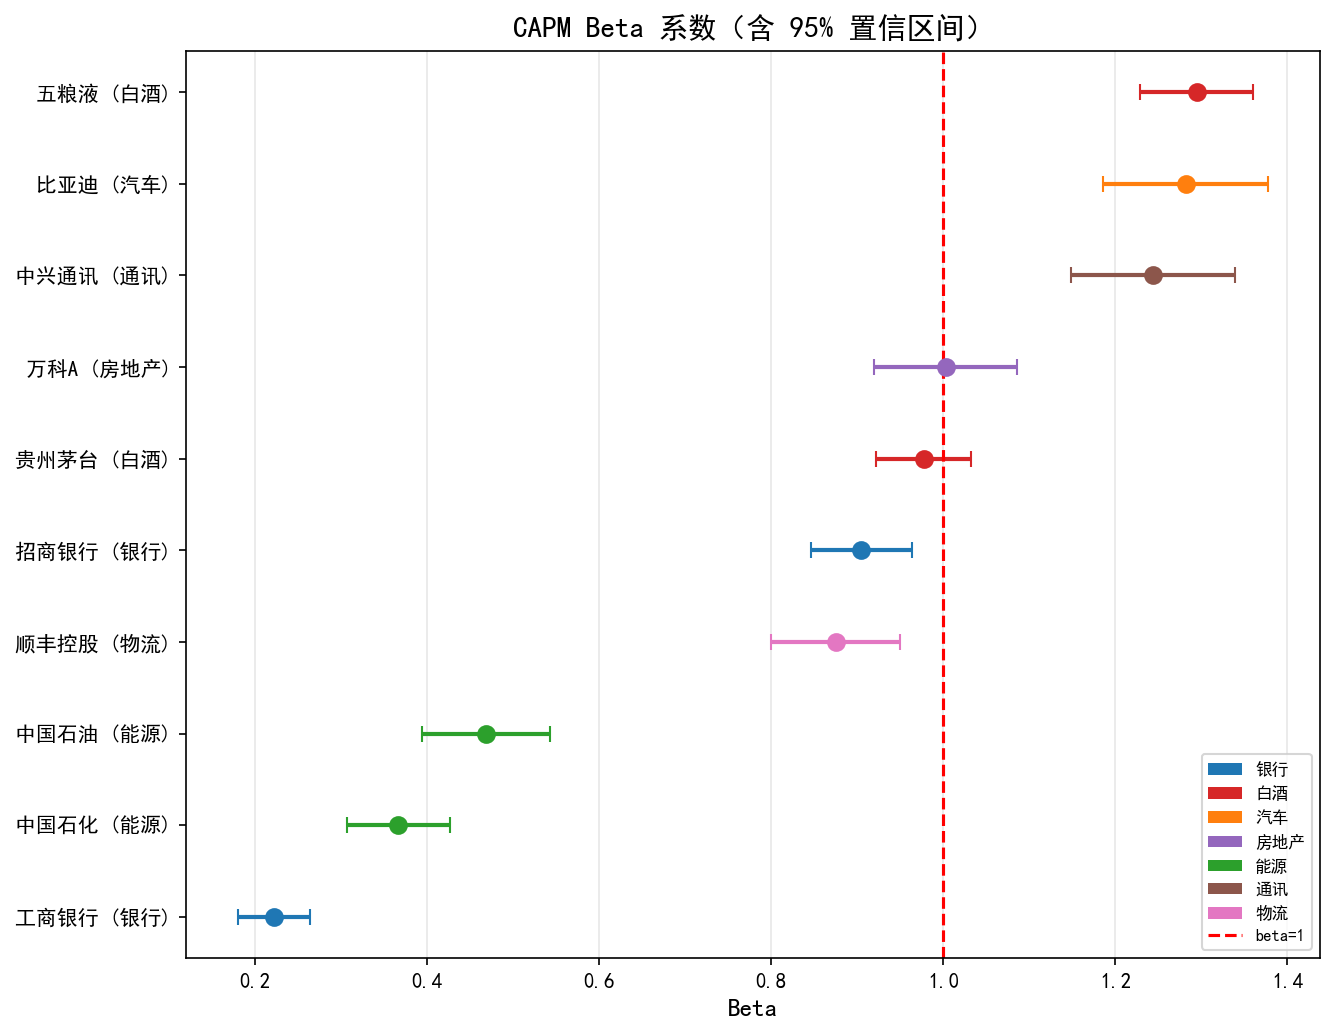

Beta 点图已保存


In [16]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 7))
df_plot = df_capm.sort_values("beta").reset_index(drop=True)

for i, row in df_plot.iterrows():
    color = INDUSTRY_COLORS[row["industry"]]
    ax.errorbar(row["beta"], i,
                xerr=[[row["beta"] - row["beta_ci_low"]], [row["beta_ci_high"] - row["beta"]]],
                fmt='o', color=color, markersize=8, capsize=4, linewidth=2)

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels([f"{r['stock']} ({r['industry']})" for _, r in df_plot.iterrows()], fontsize=10)
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Beta", fontsize=12)
ax.set_title("CAPM Beta 系数（含 95% 置信区间）", fontsize=14)
ax.grid(alpha=0.3, axis="x")

legend_elements = [Patch(facecolor=INDUSTRY_COLORS[ind], label=ind) for ind in INDUSTRY_ORDER]
legend_elements.append(plt.Line2D([0],[0], color='red', linestyle='--', label='beta=1'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_capm_beta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Beta 点图已保存")

### CAPM 分析讨论

#### 问题 1：哪些股票 beta > 1？与"周期性 vs 防御性"行业分类是否吻合？

In [17]:
high_beta = df_capm[df_capm["beta"] > 1]
low_beta = df_capm[df_capm["beta"] <= 1]

print("beta > 1 的股票（进攻型）：")
for _, r in high_beta.iterrows():
    print(f"  {r['stock']}({r['industry']}): beta = {r['beta']:.4f}")

print(f"\nbeta <= 1 的股票（防御型）：")
for _, r in low_beta.iterrows():
    print(f"  {r['stock']}({r['industry']}): beta = {r['beta']:.4f}")

beta > 1 的股票（进攻型）：
  万科A(房地产): beta = 1.0028
  中兴通讯(通讯): beta = 1.2436
  五粮液(白酒): beta = 1.2945
  比亚迪(汽车): beta = 1.2817

beta <= 1 的股票（防御型）：
  顺丰控股(物流): beta = 0.8751
  中国石化(能源): beta = 0.3668
  招商银行(银行): beta = 0.9049
  贵州茅台(白酒): beta = 0.9772
  工商银行(银行): beta = 0.2222
  中国石油(能源): beta = 0.4685


**讨论**：beta > 1 的股票通常属于周期性较强的行业。比亚迪（汽车）作为成长型科技消费股，股价对市场情绪敏感，beta 较高符合预期。白酒板块在牛市中弹性大，也可能呈现高 Beta。

beta < 1 的股票通常属于防御性行业：银行股盈利稳定、分红率高，股价波动低于大盘；能源股受油价驱动，与 A 股大盘联动性不一定强，Beta 也偏低。

这一结果整体与"周期性 vs 防御性"的行业分类逻辑吻合。

#### 问题 2：alpha 是否显著异于零？Alpha 显著意味着什么？

In [18]:
print("Alpha 显著性检验（5% 水平）：\n")
for _, r in df_capm.iterrows():
    sig = "显著 *" if r["alpha_pval"] < 0.05 else "不显著"
    d = "正" if r["alpha"] > 0 else "负"
    print(f"  {r['stock']:6s}: alpha = {r['alpha']:+.6f}, p = {r['alpha_pval']:.4f} -> {sig} ({d})")

Alpha 显著性检验（5% 水平）：

  万科A   : alpha = -0.001331, p = 0.0083 -> 显著 * (负)
  中兴通讯  : alpha = -0.000043, p = 0.9398 -> 不显著 (负)
  五粮液   : alpha = -0.000088, p = 0.8245 -> 不显著 (负)
  顺丰控股  : alpha = +0.000014, p = 0.9756 -> 不显著 (正)
  比亚迪   : alpha = +0.001180, p = 0.0428 -> 显著 * (正)
  中国石化  : alpha = +0.000275, p = 0.4467 -> 不显著 (正)
  招商银行  : alpha = +0.000138, p = 0.6968 -> 不显著 (正)
  贵州茅台  : alpha = +0.000210, p = 0.5316 -> 不显著 (正)
  工商银行  : alpha = +0.000295, p = 0.2470 -> 不显著 (正)
  中国石油  : alpha = +0.000633, p = 0.1614 -> 不显著 (正)


**讨论**：在 CAPM 框架下，alpha 代表控制了市场风险后的"超额收益"。

- **alpha 显著为正**：该股票获得了超越 CAPM 预测的回报，可能来源于公司基本面改善、行业景气度提升、或市场对其风险补偿不足。
- **alpha 显著为负**：回报低于 CAPM 预测，可能反映公司治理问题或行业衰退。
- **alpha 不显著**：回报基本可被市场风险因子解释，符合 CAPM 理论预期。

需要注意，CAPM 是单因子模型，alpha 显著性可能源于遗漏变量（如规模因子、价值因子），不能简单等同于"选股能力"。

#### 问题 3：R-squared 最高和最低的股票分别是哪只？如何解释？

In [19]:
r2_max = df_capm.loc[df_capm["R2"].idxmax()]
r2_min = df_capm.loc[df_capm["R2"].idxmin()]

print(f"R2 最高：{r2_max['stock']}({r2_max['industry']}), R2 = {r2_max['R2']:.4f}")
print(f"R2 最低：{r2_min['stock']}({r2_min['industry']}), R2 = {r2_min['R2']:.4f}")

R2 最高：五粮液(白酒), R2 = 0.4985
R2 最低：工商银行(银行), R2 = 0.0661


**讨论**：R-squared 反映了市场收益率对个股收益率的解释力度。

- **R2 高的股票**：价格变动主要由市场整体涨跌驱动，个股特异性风险较小。通常是大盘蓝筹股，流动性好、机构持仓高，走势与大盘高度同步。

- **R2 低的股票**：市场因子只能解释一小部分价格波动，大量波动来自个股特有因素（公司经营、行业独特事件、政策冲击等）。投资分析需要更多依赖基本面研究而非市场择时。

---
## 分析总结

1. **描述统计**：10 只股票在 2020-2026 年间表现分化显著，收益率均呈现尖峰厚尾特征，正态假设不适用。
2. **相关性**：同行业股票相关性显著高于跨行业，支持行业分散化投资策略。
3. **宏观因素**：M2 同比增速与沪深 300 月度收益率的同期线性关系较弱，货币政策对股市的影响存在时滞和非线性特征。
4. **CAPM 分析**：成长型/周期型行业 Beta 高于防御型行业，符合金融理论预期；R2 差异反映了不同股票受市场系统性风险驱动的程度。